Shape: (100000, 4)

Dtypes:
 Drug                   object
Demand_Forecast         int64
Optimal_Stock_Level     int64
Restocking_Strategy    object
dtype: object

Preview:
            Drug  Demand_Forecast  Optimal_Stock_Level Restocking_Strategy
0     Metformin             7750                 4753             Monthly
1    Lisinopril             5136                 9965           Quarterly
2     Metformin             3183                 2933             Monthly
3       Insulin             2332                 3927             Monthly
4  Atorvastatin             3522                 6812             Monthly

Numeric cols: ['Demand_Forecast', 'Optimal_Stock_Level']
Categorical cols: ['Drug', 'Restocking_Strategy']


/tmp/ipython-input-837089785.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipython-input-837089785.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.


Outliers in Optimal_Stock_Level: 0


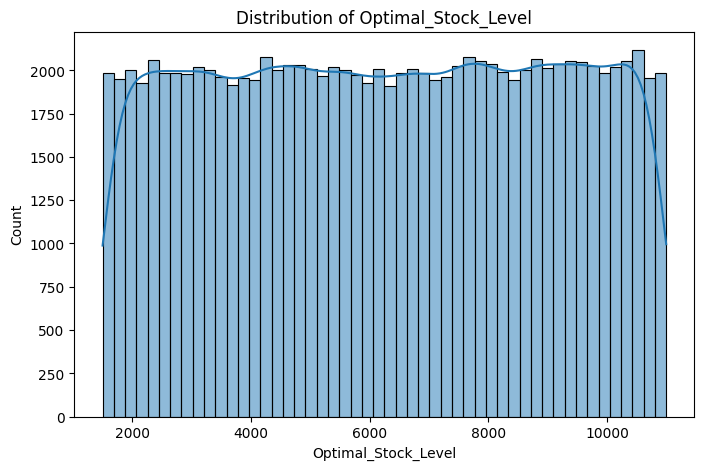

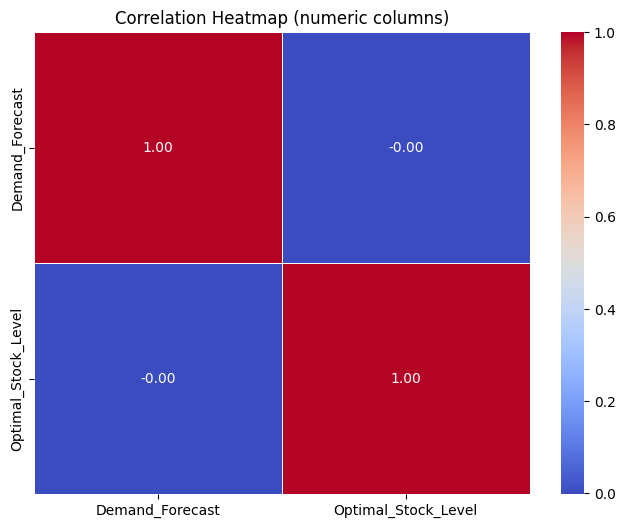


Final feature set shape: (100000, 8)
Feature sample:
    Demand_Forecast  demand_to_stock_ratio  restock_freq_per_month  \
0             7750               1.630549                1.000000   
1             5136               0.515404                0.333333   
2             3183               1.085237                1.000000   
3             2332               0.593838                1.000000   
4             3522               0.517029                1.000000   

   drug_popularity  is_high_demand  Drug_enc  restock_Quarterly  \
0            25104               1         3              False   
1            24860               0         2               True   
2            25104               0         3              False   
3            25100               0         1              False   
4            24936               0         0              False   

   restock_Weekly  
0           False  
1           False  
2           False  
3           False  
4           False  

Model 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Load dataset
df = pd.read_csv('Pharmaceutical Supply Chain Optimization.csv')

# 2. Understand dataset
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nPreview:\n", df.head())

# We'll use Optimal_Stock_Level as the target (equivalent to 'total_cost' in your original code)
TARGET = 'Optimal_Stock_Level'

# 3. Handle missing values
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category','bool']).columns.tolist()

print("\nNumeric cols:", numeric_cols)
print("Categorical cols:", cat_cols)

for col in numeric_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

for col in cat_cols:
    mode_val = df[col].mode().iloc[0] if not df[col].mode().empty else ''
    df[col].fillna(mode_val, inplace=True)

# 4. Outlier detection (IQR) for target and main numeric features
def detect_outliers_iqr(series):
    q1, q3 = series.quantile([.25, .75])
    iqr = q3 - q1
    return series[(series < q1 - 1.5*iqr) | (series > q3 + 1.5*iqr)]

outliers_target = detect_outliers_iqr(df[TARGET])
print(f'\nOutliers in {TARGET}: {len(outliers_target)}')

if len(outliers_target) > 0:
    print(df.loc[outliers_target.index].head())

# 5. EDA
plt.figure(figsize=(8,5))
sns.histplot(df[TARGET], bins=50, kde=True)
plt.title(f'Distribution of {TARGET}')
plt.xlabel(TARGET)
plt.show()

plt.figure(figsize=(8,6))
num_df = df.select_dtypes(include=[np.number])
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap (numeric columns)')
plt.show()

# 6. Feature engineering
eps = 1e-6
df['demand_to_stock_ratio'] = df['Demand_Forecast'] / (df['Optimal_Stock_Level'] + eps)

def restock_freq(strategy):
    s = str(strategy).lower()
    if 'weekly' in s: return 4.0
    if 'biweekly' in s or 'fortnight' in s: return 2.0
    if 'monthly' in s: return 1.0
    if 'quarter' in s: return 1.0/3.0
    if 'annual' in s or 'year' in s: return 1.0/12.0
    return 1.0

df['restock_freq_per_month'] = df['Restocking_Strategy'].apply(restock_freq)

df['drug_popularity'] = df['Drug'].map(df['Drug'].value_counts())

median_demand = df['Demand_Forecast'].median()
df['is_high_demand'] = (df['Demand_Forecast'] > median_demand).astype(int)

# 7. Encode categorical variables
le_drug = LabelEncoder()
df['Drug_enc'] = le_drug.fit_transform(df['Drug'])

df = pd.get_dummies(df, columns=['Restocking_Strategy'], prefix=['restock'], drop_first=True)

# 8. Prepare features/target
drop_cols = ['Drug']
if TARGET in drop_cols:
    drop_cols.remove(TARGET)
X = df.drop(columns=drop_cols + [TARGET])
y = df[TARGET].copy()

print("\nFinal feature set shape:", X.shape)
print("Feature sample:\n", X.head())

# 9. Split & scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

scaler = StandardScaler().fit(X_train.select_dtypes(include=[np.number]))
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

def scale_df(X_df, scaler, numeric_cols):
    X_scaled = X_df.copy()
    X_scaled[numeric_cols] = scaler.transform(X_scaled[numeric_cols])
    return X_scaled

X_train_s = scale_df(X_train, scaler, num_features)
X_test_s  = scale_df(X_test, scaler, num_features)

# 10. Models
lr = LinearRegression().fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

gb = GradientBoostingRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

# 11. Evaluate
def eval_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'{name}: RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.4f}')

print("\nModel performance on test set:")
eval_model('Linear Regression', y_test, y_pred_lr)
eval_model('Random Forest',     y_test, y_pred_rf)
eval_model('Gradient Boosting', y_test, y_pred_gb)

# 12. Hyperparameter tuning (example for GB)
param_grid = {
    'n_estimators':[50,100],
    'learning_rate':[0.05,0.1],
    'max_depth':[3,4]
}
gscv = GridSearchCV(GradientBoostingRegressor(random_state=42),
                    param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
gscv.fit(X_train, y_train)
best_gb = gscv.best_estimator_
print('\nBest GB params:', gscv.best_params_)

# 13. Cross-validation of best model
cv_scores = cross_val_score(best_gb, X, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
cv_rmse = np.sqrt(-cv_scores)
print('\nGB CV RMSE scores:', np.round(cv_rmse,3))
print('GB CV RMSE Mean:', np.round(cv_rmse.mean(),3), 'Std:', np.round(cv_rmse.std(),3))

# 14. Feature importance (best model)
importances = pd.Series(best_gb.feature_importances_, index=X.columns)
print('\nTop 15 features by importance:\n', importances.sort_values(ascending=False).head(15))

topN = 15
plt.figure(figsize=(8,6))
importances.sort_values(ascending=False).head(topN).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top feature importances (GB - tuned)')
plt.xlabel('Importance')
plt.show()
